# M1.Ex3: Iris Classification

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex3_class.ipynb)
- Dataset:`sklearn.datasets.load_iris()`

In [1]:
import pandas as pd
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.inspection import DecisionBoundaryDisplay

![Iris Flowers](https://github.com/HassanAlgoz/B5/blob/main/content/W3/M1/assets/iris_flowers.png?raw=1)

### Step 1.a Load the data

In [2]:
iris = sklearn.datasets.load_iris(as_frame=True)

In [3]:
df = iris.frame
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


### Step 2.a Assign variables `X` to the features and `y` to the target

In [4]:
X = iris.data
y = iris.target

### Step 2.b print the type of each

In [5]:
X.dtypes

,0
sepal length (cm),float64
sepal width (cm),float64
petal length (cm),float64
petal width (cm),float64


In [6]:
y.dtypes

dtype('int64')

### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

* Target is: categorical [0 = setosa, 1 = versicolor, and 2 = virginica, are actually labels (categories), not quantities].
* Task is: classification

### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [7]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (150, 4)
y shape: (150,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [8]:
X.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [9]:
y.describe()

,target
count,150.000000
mean,1.000000
std,0.819232
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,2.000000


### Step 5. Plot the features to identify separability. Can you see clearly distinguishable groups of points?

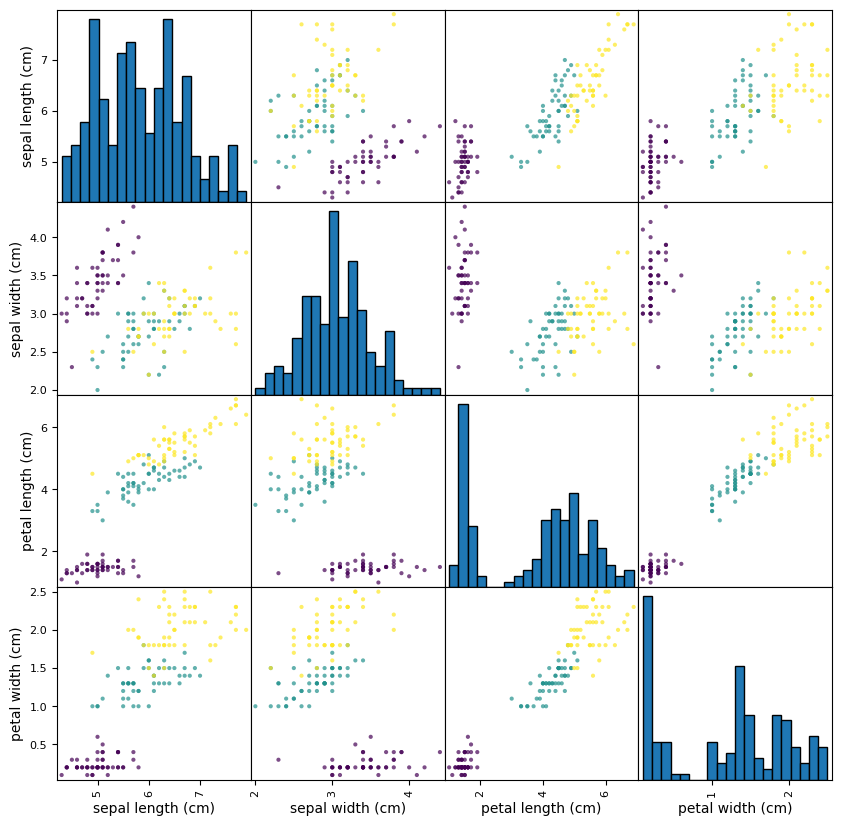

In [10]:
scatter_matrix(X, c=y, diagonal='hist', hist_kwds={"bins": 20, "edgecolor": "black"}, figsize=(10,10), alpha=0.7)
plt.show()

* Yes, but only when using the petal features (petal length and petal width), which show three clearly separated clusters, making
the species easy to distinguish. While the sepal features (sepal length and sepal width) show much more overlap, so the species
are not easily distinguishable from sepal measurements alone.

### Step 6. Keep the following in "Steps 7" onwards

1. First model will trian on the features: `sepal length (cm)` & `sepal width (cm)`
2. Second model will train on the features: `petal length (cm)` & `petal width (cm)`

Finally, evaluate and compare which of the two feature-sets scored better.

Let's do both subsets now..

### Step 6.a subset the features `sepal length (cm)` & `sepal width (cm)`


In [11]:
X_sepal = X[['sepal length (cm)', 'sepal width (cm)']]

### Step 6.b subset the features `petal length (cm)` & `petal width (cm)`


In [12]:
X_petal = X[['petal length (cm)', 'petal width (cm)']]

### Step 7. Initialize 2 `LogisticRegression` models

In [13]:
sepal_model = LogisticRegression()
petal_model = LogisticRegression()

### Step 8. Split the dataset into train and test sets (remember to stratify by the target to account for class imbalance)

* NOTE: The underscores _ are placeholders used to ignore the y_train and y_test outputs from the second train_test_split, since the
target was already split in the first call. They use the same y.

In [14]:
X_train_sepal, X_test_sepal, y_train, y_test = train_test_split(X_sepal, y, test_size=0.2,random_state=42, stratify=y)
X_train_petal, X_test_petal, _, _ = train_test_split( X_petal, y, test_size=0.2, random_state=42, stratify=y)

### Step 9.a Train both models

In [15]:
sepal_model.fit(X_train_sepal, y_train)
petal_model.fit(X_train_petal, y_train)

LogisticRegression()

### Step 10. Evaluate and compare both models

In [16]:
sepal_model.score(X_test_sepal, y_test)

0.7333333333333333

In [17]:
petal_model.score(X_test_petal, y_test)

0.9666666666666667

### Step 11. Which of the two subset of features better distinguishes iris flowers? Can you easily tell?

* Yes, the petal model is better (with the score = 0.96).


### Step 12. Use `DecisionBoundaryDisplay` to plot the learned decision boundary

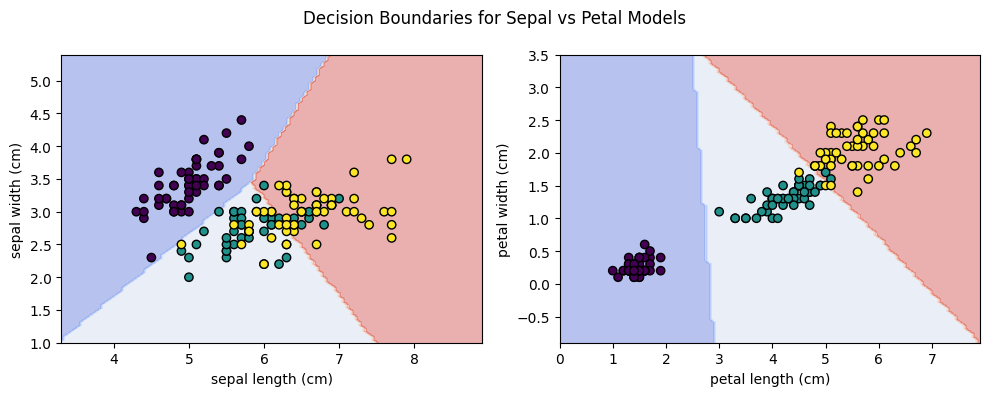

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sepal Model  -->  axes[0] → left subplot

DecisionBoundaryDisplay.from_estimator(sepal_model, X_sepal, response_method="predict", cmap="coolwarm", alpha=0.4, ax=axes[0])
axes[0].scatter(X_sepal.iloc[:,0], X_sepal.iloc[:,1], c=y, edgecolor="black")
axes[0].set_xlabel("sepal length (cm)")
axes[0].set_ylabel("sepal width (cm)")

# Petal Model  -->  axes[1] → right subplot

DecisionBoundaryDisplay.from_estimator(petal_model, X_petal, response_method="predict", cmap="coolwarm", alpha=0.4, ax=axes[1])
axes[1].scatter(X_petal.iloc[:,0], X_petal.iloc[:,1], c=y, edgecolor="black")
axes[1].set_xlabel("petal length (cm)")
axes[1].set_ylabel("petal width (cm)")

fig.suptitle("Decision Boundaries for Sepal vs Petal Models")
plt.tight_layout()
plt.show()